In [10]:
import os

from physics.hstar import c6
from physics.hzz import zz4l, zpair
from physics.simulation import mcfm, msq

import numpy as np
import matplotlib.pyplot as plt

import hist

In [11]:
SAMPLE_DIR = '../..'
SAMPLE_SIZE = 2000000
COMPONENT = msq.Component.SBI

In [12]:
filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

In [13]:
sample = mcfm.from_csv(cross_section=xs[COMPONENT], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT]))

bkg_null_filter = msq.MSQFilter('msq_bkg_sm', value=0.0)
bkg_nan_filter = msq.MSQFilter('msq_bkg_sm', value=np.nan)

z_candidate = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1 = (70,115), z2 = (70,115))

angles = zz4l.AngularVariables()
four_lepton = zz4l.FourLeptonSystem()

sample_processed = sample.filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)#[:SAMPLE_SIZE]

features = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

# Get only required features
kinematics = sample_processed.kinematics[features].to_numpy()

15.573816383864997


In [14]:
print(kinematics.shape)

(2856608, 9)


In [15]:
mod_c6 = c6.Modifier(baseline = COMPONENT, events=sample_processed, c6_values = [-5,-1,0,1,5])
weights_c6, prob_c6 = mod_c6.modify(c6=[-10,10])

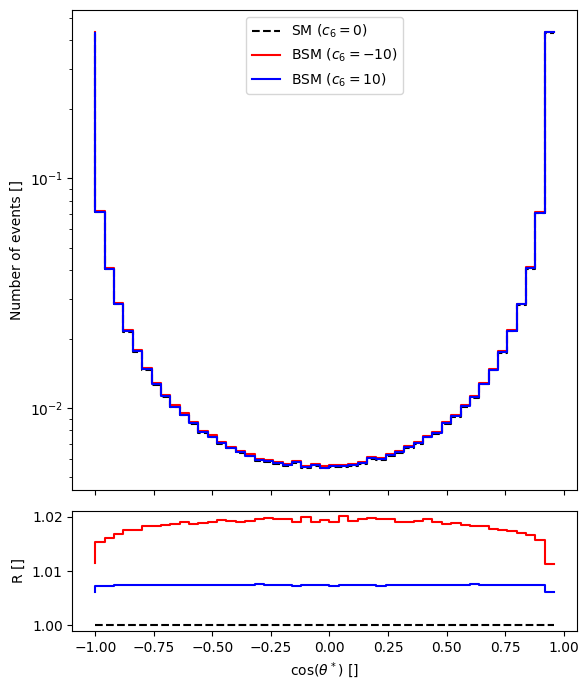

In [16]:
cth_str = kinematics[:,0]

BINS=50

hist_sm, bins = np.histogram(cth_str, bins=BINS, range=(-1,1), weights=sample_processed.weights)
hist_c6_1, bins = np.histogram(cth_str, bins=BINS, range=(-1,1), weights=weights_c6.T[0])
hist_c6_2, bins = np.histogram(cth_str, bins=BINS, range=(-1,1), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[:-1], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[:-1], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$\mathrm{cos}(\\theta^*)$ []')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

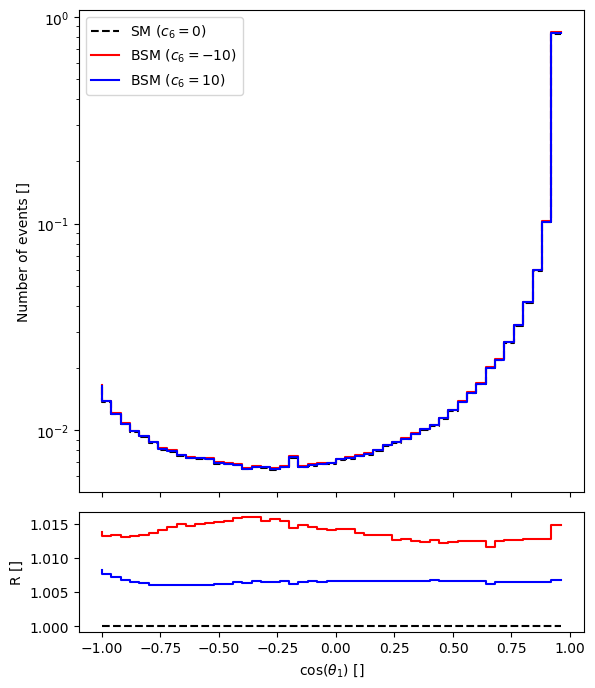

In [17]:
cth1 = kinematics[:,1]

BINS=50

hist_sm, bins = np.histogram(cth1, bins=BINS, range=(-1,1), weights=sample_processed.weights)
hist_c6_1, bins = np.histogram(cth1, bins=BINS, range=(-1,1), weights=weights_c6.T[0])
hist_c6_2, bins = np.histogram(cth1, bins=BINS, range=(-1,1), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[:-1], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[:-1], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$\mathrm{cos}(\\theta_1)$ []')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

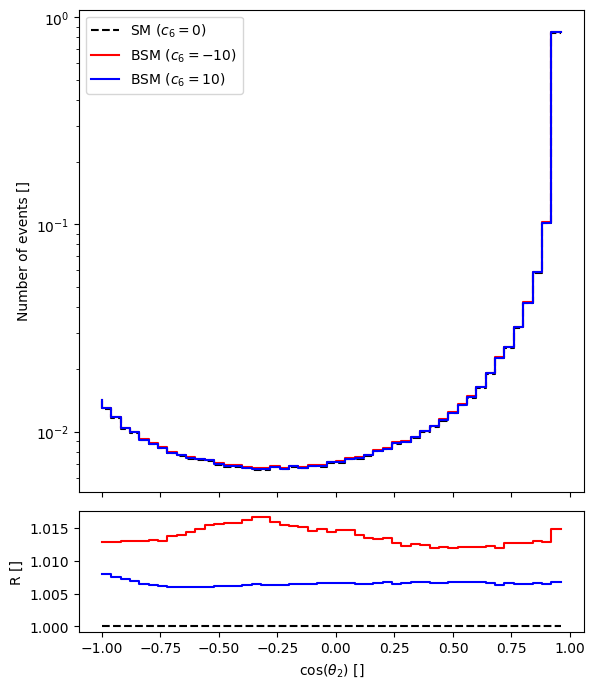

In [18]:
cth2 = kinematics[:,2]

BINS=50

hist_sm, bins = np.histogram(cth2, bins=BINS, range=(-1,1), weights=sample_processed.weights)
hist_c6_1, bins = np.histogram(cth2, bins=BINS, range=(-1,1), weights=weights_c6.T[0])
hist_c6_2, bins = np.histogram(cth2, bins=BINS, range=(-1,1), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[:-1], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[:-1], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$\mathrm{cos}(\\theta_2)$ []')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

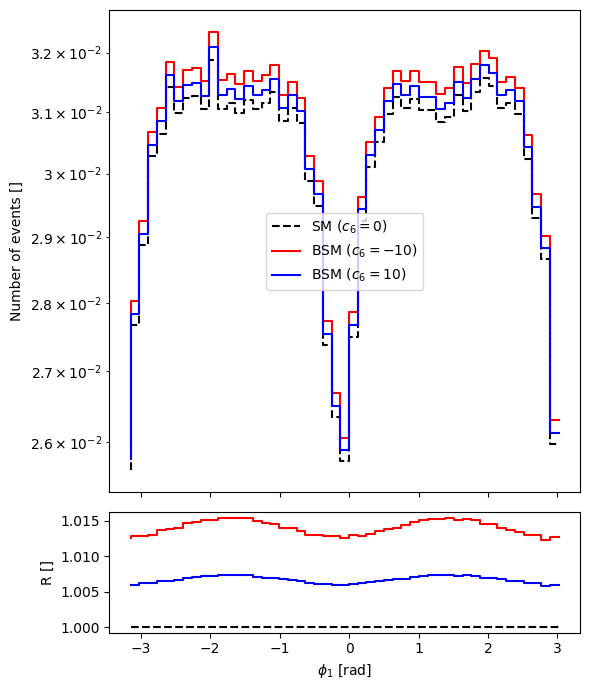

In [19]:
phi1 = kinematics[:,3]

BINS=50

hist_sm, bins = np.histogram(phi1, bins=BINS, range=(-np.pi,np.pi), weights=sample_processed.weights)
hist_c6_1, bins1 = np.histogram(phi1, bins=BINS, range=(-np.pi,np.pi), weights=weights_c6.T[0])
hist_c6_2, bins2 = np.histogram(phi1, bins=BINS, range=(-np.pi,np.pi), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[:-1], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[:-1], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$\phi_1$ [rad]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

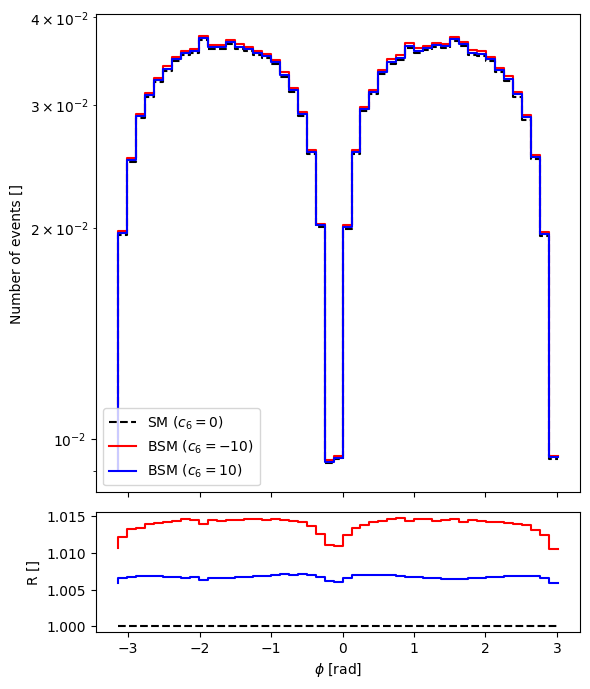

In [20]:
phi = kinematics[:,4]

BINS=50

hist_sm, bins = np.histogram(phi, bins=BINS, range=(-np.pi,np.pi), weights=sample_processed.weights)
hist_c6_1, bins = np.histogram(phi, bins=BINS, range=(-np.pi,np.pi), weights=weights_c6.T[0])
hist_c6_2, bins = np.histogram(phi, bins=BINS, range=(-np.pi,np.pi), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[:-1], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[:-1], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$\phi$ [rad]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

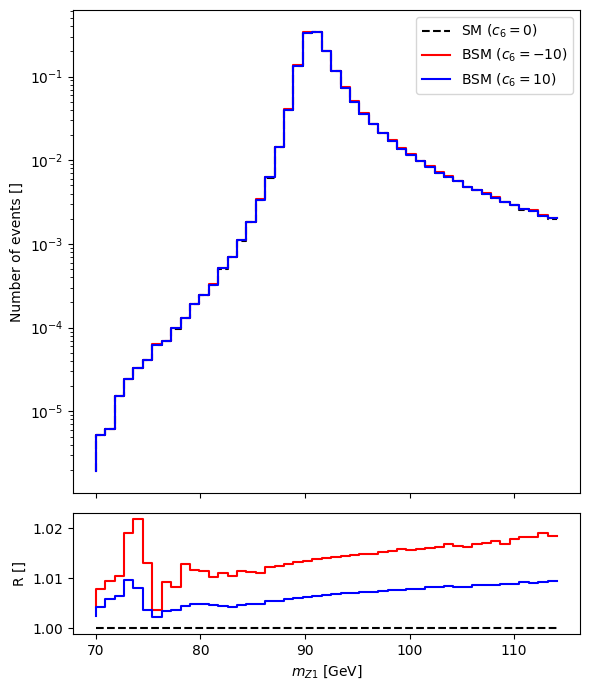

In [21]:
mZ1 = kinematics[:,5]

BINS=50

hist_sm, bins = np.histogram(mZ1, bins=BINS, range=(70,115), weights=sample_processed.weights)
hist_c6_1, bins = np.histogram(mZ1, bins=BINS, range=(70,115), weights=weights_c6.T[0])
hist_c6_2, bins = np.histogram(mZ1, bins=BINS, range=(70,115), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[:-1], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[:-1], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$m_{Z1}$ [GeV]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)

fig.tight_layout()

plt.show()

In [22]:
print(np.sum((kinematics[:,6]<=50).astype(int)))
print(np.min(kinematics[:,6]))

0
70.00005922339233


/tmp/ipykernel_2194788/2276391004.py:22: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
/tmp/ipykernel_2194788/2276391004.py:23: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
/tmp/ipykernel_2194788/2276391004.py:24: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')


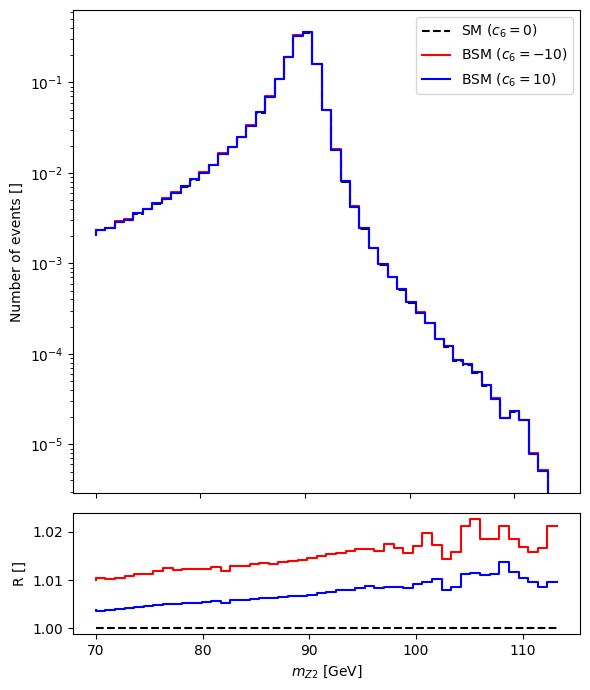

In [23]:
mZ2 = kinematics[:,6]

BINS=50

hist_sm, bins = np.histogram(mZ2, bins=BINS, range=(70,115), weights=sample_processed.weights)
hist_c6_1, bins = np.histogram(mZ2, bins=BINS, range=(70,115), weights=weights_c6.T[0])
hist_c6_2, bins = np.histogram(mZ2, bins=BINS, range=(70,115), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[:-1], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[:-1], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')

ax1.legend()

ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$m_{Z2}$ [GeV]')
ax2.set_ylabel('R []')

fig.tight_layout()

plt.show()

/tmp/ipykernel_2194788/3557558225.py:23: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
/tmp/ipykernel_2194788/3557558225.py:24: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
/tmp/ipykernel_2194788/3557558225.py:25: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')


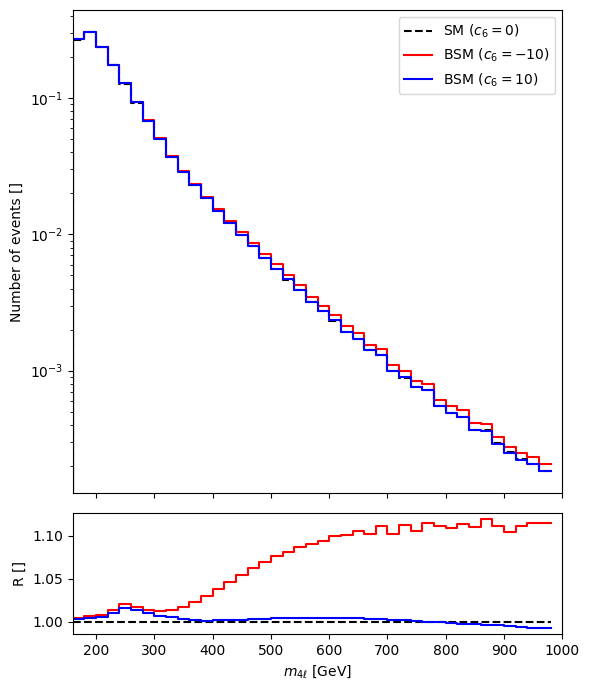

In [24]:
mZ2 = kinematics[:,7]

BINS=50

hist_sm, bins = np.histogram(mZ2, bins=BINS, range=(0,1000), weights=sample_processed.weights)
hist_c6_1, bins = np.histogram(mZ2, bins=BINS, range=(0,1000), weights=weights_c6.T[0])
hist_c6_2, bins = np.histogram(mZ2, bins=BINS, range=(0,1000), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[:-1], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[:-1], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')
ax1.set_xlim(160,1000)

ax1.legend()

ax2.step(bins[:-1], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[:-1], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[:-1], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$m_{4\ell}$ [GeV]')
ax2.set_ylabel('R []')
#ax2.set_ybound(0.99,1.02)
ax2.set_xlim(160,1000)

fig.tight_layout()

plt.show()

-0.010566340120986544


/tmp/ipykernel_2194788/692891368.py:25: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[1:], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
/tmp/ipykernel_2194788/692891368.py:26: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[1:], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
/tmp/ipykernel_2194788/692891368.py:27: RuntimeWarning: invalid value encountered in divide
  ax2.step(bins[1:], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')


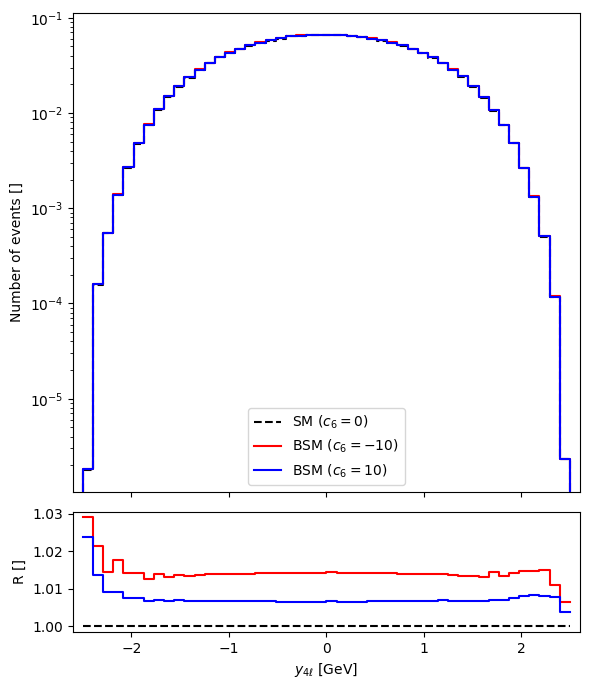

In [25]:
mZ2 = kinematics[:,8]

print(np.mean(mZ2))

BINS=50

hist_sm, bins = np.histogram(mZ2, bins=BINS, range=(-2.6,2.6), weights=sample_processed.weights)
hist_c6_1, bins = np.histogram(mZ2, bins=BINS, range=(-2.6,2.6), weights=weights_c6.T[0])
hist_c6_2, bins = np.histogram(mZ2, bins=BINS, range=(-2.6,2.6), weights=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[1:], hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax1.step(bins[1:], hist_c6_1, color='r', label=u'BSM ($c_6=-10$)')
ax1.step(bins[1:], hist_c6_2, color='b', label=u'BSM ($c_6=10$)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')
ax1.set_xbound(-2.6,2.6)
#ax1.grid()
ax1.legend()

ax2.step(bins[1:], hist_sm/hist_sm, color='k', linestyle='--', label=u'SM ($c_6=0$)')
ax2.step(bins[1:], hist_c6_1/hist_sm, color='r', label=u'BSM ($c_6=-10$)')
ax2.step(bins[1:], hist_c6_2/hist_sm, color='b', label=u'BSM ($c_6=10$)')

ax2.set_xlabel(u'$y_{4\ell}$ [GeV]')
ax2.set_ylabel('R []')
ax2.set_xbound(-2.6,2.6)

fig.tight_layout()

plt.show()

In [73]:
sample_2 = mcfm.from_csv(cross_section=xs[COMPONENT], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT]), n_rows=10000)

bkg_null_filter = msq.MSQFilter('msq_bkg_sm', value=0.0)
bkg_nan_filter = msq.MSQFilter('msq_bkg_sm', value=np.nan)

z_candidate = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1 = (70,115), z2 = (70,115))

angles = zz4l.AngularVariables()
four_lepton = zz4l.FourLeptonSystem()

sample_processed_2 = sample_2.filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)#[:SAMPLE_SIZE]

features = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

# Get only required features
kinematics_2 = sample_processed_2.kinematics[features].to_numpy()

0.05366509182760999


In [74]:
mod_c6_2 = c6.Modifier(baseline = COMPONENT, events=sample_processed_2, c6_values = [-5,-1,0,1,5])
weights_c6_2, prob_c6_2 = mod_c6_2.modify(c6=[-10,10])

/tmp/ipykernel_2194788/2542000608.py:54: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].edges[:-1], hist_sm.values()/hist_sm.values(), yerr=np.sqrt(hist_sm.variances())/hist_sm.values(), color='black', linestyle='--', drawstyle='steps-pre', alpha=0.8)
/tmp/ipykernel_2194788/2542000608.py:55: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].edges[:-1], hist_c6_1.values()/hist_sm.values(), color='r', drawstyle='steps-pre')
/tmp/ipykernel_2194788/2542000608.py:56: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(hist_sm.axes[0].edges[:-1], hist_c6_2.values()/hist_sm.values(), color='b', drawstyle='steps-pre')


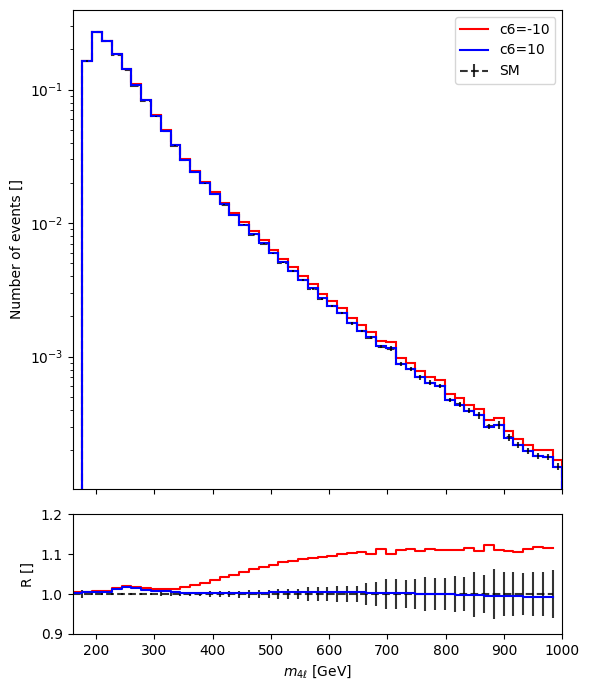

In [83]:
index = 7

kin_var = kinematics[:,index]
label = ['$\mathrm{cos}(\\theta^*)$ []',
         '$\mathrm{cos}(\\theta_1)$ []',
         '$\mathrm{cos}(\\theta_2)$ []',
         '$\phi$ []',
         '$\phi_1$ []',
         '$m_{Z1}$ [GeV]',
         '$m_{Z2}$ [GeV]',
         '$m_{4\ell}$ [GeV]',
         '$y_{4\ell}$ []'][index]
bounds = [[-1,1],
          [-1,1],
          [-1,1],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [70,115],
          [70,115],
          [160,1000],
          [-2.4,2.4]][index]


BINS=50

hist_sm = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_sm.fill(kin_var, weight=sample_processed.weights.to_numpy())

hist_c6_1 = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_c6_1.fill(kin_var, weight=weights_c6.T[0])

hist_c6_2 = hist.Hist(hist.axis.Regular(BINS, *bounds), storage=hist.storage.Weight())
hist_c6_2.fill(kin_var, weight=weights_c6.T[1])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

hist_sm.plot(ax=ax1, color='k', linestyle='--', label=f'SM', alpha=0.8, yerr=np.sqrt(hist_sm.variances()))
hist_c6_1.plot(ax=ax1, color='r', label=f'c6=-10', yerr=False)
hist_c6_2.plot(ax=ax1, color='b', label=f'c6=10', yerr=False)

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')
ax1.set_xlim(*bounds)
ax1.set_xlabel('')

ax1.legend()

#hist_sm.plot_ratio(hist_sm)
#hist_c6_1.plot_ratio(hist_sm)
#hist_c6_2.plot_ratio(hist_sm)

ax2.errorbar(hist_sm.axes[0].edges[:-1], hist_sm.values()/hist_sm.values(), yerr=np.sqrt(hist_sm.variances())/hist_sm.values(), color='black', linestyle='--', drawstyle='steps-pre', alpha=0.8)
ax2.errorbar(hist_sm.axes[0].edges[:-1], hist_c6_1.values()/hist_sm.values(), color='r', drawstyle='steps-pre')
ax2.errorbar(hist_sm.axes[0].edges[:-1], hist_c6_2.values()/hist_sm.values(), color='b', drawstyle='steps-pre')
         
ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
ax2.set_ybound(0.9,1.2)
ax2.set_xlim(*bounds)
fig.tight_layout()

plt.show()